--- Đang thực hiện thí nghiệm Bán giám sát ---


c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SelfTrainingClassifier was fitted with feature names
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SelfTrainingClassifier was fitted with feature names
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\

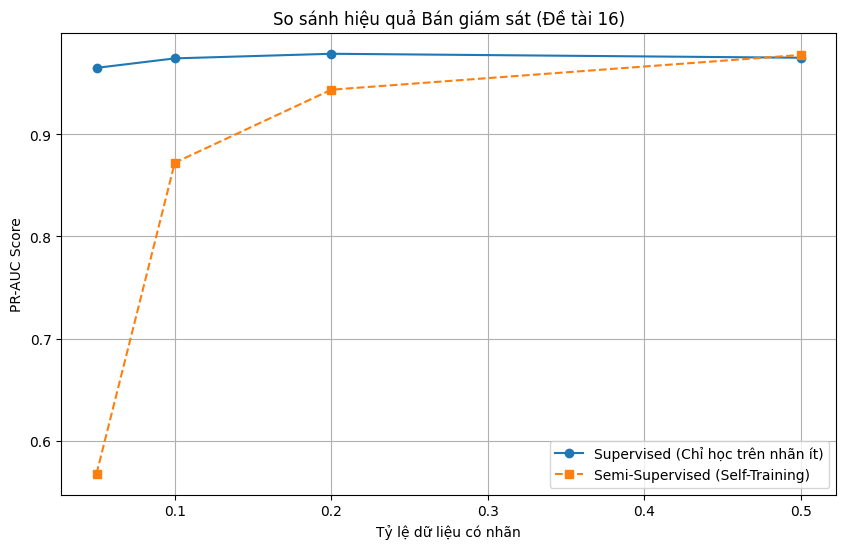

✅ Hoàn thành 04b: Biểu đồ và dữ liệu so sánh đã được lưu vào outputs/


In [3]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import re
import joblib
from sklearn.model_selection import train_test_split
sys.path.append(os.path.abspath(".."))

from src.data.loader import load_config
from src.models.semi_supervised import prepare_semi_supervised_data, train_self_training
from src.evaluation.metrics import evaluate_model
from sklearn.ensemble import RandomForestClassifier

# 1. Load dữ liệu và tiền xử lý đồng bộ
config = load_config("../configs/params.yaml")
df = pd.read_csv("../data/processed/cleaned_data.csv")

if 'Type' in df.columns:
    df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})
if 'Product ID' in df.columns:
    df = df.drop(columns=['Product ID'])

df.columns = [re.sub(r'[\[\]<]', '', col) for col in df.columns]

X = df.drop(columns=[config['features']['target']])
y = df[config['features']['target']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Thiết lập thí nghiệm Learning Curve
label_fractions = [0.05, 0.1, 0.2, 0.5]
results_supervised = []
results_semi = []

print("--- Đang thực hiện thí nghiệm Bán giám sát ---")
for frac in label_fractions:
    # Giả lập thiếu nhãn
    y_semi = prepare_semi_supervised_data(y_train, fraction=frac)
    
    # Nhánh Supervised: Chỉ học trên phần có nhãn
    X_lab = X_train[y_semi != -1]
    y_lab = y_semi[y_semi != -1]
    clf_sup = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42)
    clf_sup.fit(X_lab, y_lab)
    _, auc_sup = evaluate_model(clf_sup, X_test.values, y_test)
    results_supervised.append(auc_sup)
    
    # Nhánh Semi-supervised: Tận dụng toàn bộ dữ liệu
    clf_semi = train_self_training(X_train, y_semi, config)
    _, auc_semi = evaluate_model(clf_semi, X_test.values, y_test)
    results_semi.append(auc_semi)

# 3. Trực quan hóa và LƯU BIỂU ĐỒ
plt.figure(figsize=(10, 6))
plt.plot(label_fractions, results_supervised, 'o-', label='Supervised (Chỉ học trên nhãn ít)')
plt.plot(label_fractions, results_semi, 's--', label='Semi-Supervised (Self-Training)')
plt.xlabel('Tỷ lệ dữ liệu có nhãn')
plt.ylabel('PR-AUC Score')
plt.title('So sánh hiệu quả Bán giám sát (Đề tài 16)')
plt.legend()
plt.grid(True)

# BỔ SUNG: Lưu biểu đồ vào outputs/figures
plt.savefig("../outputs/figures/semi_supervised_learning_curve.png", bbox_inches='tight')
plt.show()

# 4. Lưu kết quả định lượng vào outputs/tables
comparison_df = pd.DataFrame({
    'Label_Fraction': label_fractions,
    'Supervised_PR_AUC': results_supervised,
    'Semi_Supervised_PR_AUC': results_semi
})
comparison_df.to_csv("../outputs/tables/semi_supervised_comparison.csv", index=False)

# BỔ SUNG: Lưu mô hình Semi-supervised tốt nhất (phiên bản cuối cùng)
joblib.dump(clf_semi, '../outputs/models/model_semi_final.pkl')

print("✅ Hoàn thành 04b: Biểu đồ và dữ liệu so sánh đã được lưu vào outputs/")